# Simulation of a 2-DOF Planar Manipulator for Logo Tracing

Okay so before I start with this, I'll just explain my approach. We need to trace the IIT KGP Logo using a Robotic Arm Having 2 Degrees of Freedom. Since it's tough to basically find all the points manually and feed it into the robotic arm algorithm, I've created a copy of the KGP Logo that basically contains only edges in it. Let me show you...
<div align="center">
    <img src="../data/kgp_logo.png" width="350">
</div>

Now, since we have only 2 DOF, the arm cannot lift the pen up, i.e. it must draw without lifting the pen up. Thus, it cannot draw between disconnected points. So if you observe the image closely, I've connected as many chunks of white pixels as possible (I used Canva for that). Now I just have to write a function to find and store these points so that it can use it for drawing later.

In [1]:
# First I'll import important modules
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Extracting Largest Component

Now I'm going to write a function that basically takes in the image part and checks for the largest connected component of white pixels (since I've made the image that way). It'll basically take all the pixels which are non-black after thresholding so yeah even different shades of white work. That's how editing in canva turned out helpful.

In [2]:
# Now this function should take in an edge-detected image and extracts pixels as (x, y) coords
def extract_largest_component(image_path):
    # Load the image in grayscale
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError(f"Could not load image at {image_path}. Check the path.")

    # Threshold the image to ensure pure binary (white edges, black background)
    _, binary = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)

    # Find connected components
    # connectivity=8 means diagonals are considered connected
    # (Took me some effort to find that out and fix it)
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(binary, connectivity=8)

    # Find the largest component (excluding label 0, which is the black background)
    largest_label = 1
    max_area = 0
    for i in range(1, num_labels):
        if stats[i, cv2.CC_STAT_AREA] > max_area:
            max_area = stats[i, cv2.CC_STAT_AREA]
            largest_label = i

    # Extract the coordinates of the largest component
    # np.where returns (row, col) which translates to (y, x). 
    # We invert it to standard (x, y) Cartesian coordinates for the robot.
    y_coords, x_coords = np.where(labels == largest_label)
    
    # In images, Y goes down. For a robot workspace, we usually want Y going up.
    # We will flip the Y coordinates based on the image height.
    height = img.shape[0]
    points = np.column_stack((x_coords, height - y_coords))

    print(f"Extraction complete: Found {len(points)} points in the largest component.")
    
    return points

Now that we have that function, we might also want a function to visually confirm that our points are right. Otherwise there'll be problems later in the program. So I guess we go onto that.

# Visualise Extracted Points

In [3]:
def visualize_points(points, mode):
    # Slice the numpy array into separate X and Y lists
    x = points[:, 0]
    y = points[:, 1]

    plt.figure(figsize=(8, 8))

    if(mode=="scatter"):
        # Scatter plot with small dot markers
        plt.scatter(x, y, s=1, c='blue', marker='.')
    elif(mode=="plot"):
        # Use plt.plot instead of plt.scatter to draw connected lines
        plt.plot(x, y, color='red', linewidth=0.5, alpha=0.8)
        
    
    plt.title("Extracted Points (Robot Workspace)")
    plt.xlabel("X Coordinate")
    plt.ylabel("Y Coordinate")
    
    # Force the axes to have the same scale so the logo isn't stretched
    plt.axis('equal') 
    plt.grid(True)
    plt.show()

I realised I haven't really called the functions, so I'll just do that now.

# Calling Functions on Edge-Detected Image

Extraction complete: Found 5307 points in the largest component.


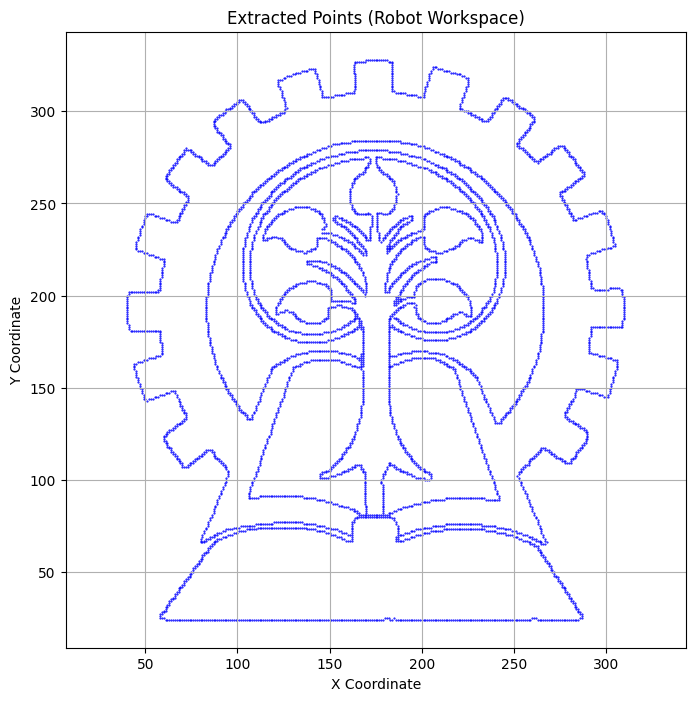

In [4]:
raw_points = extract_largest_component('../data/kgp_logo.png')
visualize_points(raw_points, "scatter")

# Creating a Smooth Path for Drawing

So now I do have the points, but I need an algorithm to decipher the path chosen by the robotic arm, such that maximum points are touched by the end effector. Now I tried to basically create a path using nearest neighbours and all that but it failed because it was dragging lines left right center (I decided not to record it because it was way too ugly). I figured out that the problem was that towards the end, when very few points are unvisited, the nearest neighbour to a point can be even a hundred pixels away, and that's not a good thing. If the end effector moves from current pixel to a pixel 100 pixels away just because it is the closest, it'll end up tracing every pixel on the way. So I decided to threshold it using a variable called `max_jump`. Let me show you my function.

In [5]:
"""
Sorts points using nearest-neighbor, but completely stops drawing 
if the next closest point is further than the max_jump threshold.
"""

def sort_path(points, max_jump=10.0):
    print(f"Starting path generation from {len(points)} raw points...")
    
    if len(points) == 0:
        return points

    unvisited_indices = list(range(len(points)))
    sorted_points = []
    
    # Start drawing from the very first point
    current_idx = unvisited_indices.pop(0)
    sorted_points.append(points[current_idx])

    while unvisited_indices:
        current_point = sorted_points[-1]
        remaining_points = points[unvisited_indices]
        
        # Calculate distances to all remaining points
        distances = np.linalg.norm(remaining_points - current_point, axis=1)
        
        # Find the absolute closest point
        closest_relative_idx = np.argmin(distances)
        min_distance = distances[closest_relative_idx]
        
        # Break Condition
        if min_distance > max_jump:
            print(f"Gap of {min_distance:.2f} pixels detected. Stopping the draw.")
            break
        
        # If it's within the threshold, add it to the path and keep going
        closest_actual_idx = unvisited_indices.pop(closest_relative_idx)
        sorted_points.append(points[closest_actual_idx])

    print(f"Finished! The arm will draw a continuous line of {len(sorted_points)} points.")
    return np.array(sorted_points)

In [6]:
sorted_path = sort_path(raw_points)

Starting path generation from 5307 raw points...
Gap of 86.68 pixels detected. Stopping the draw.
Finished! The arm will draw a continuous line of 4742 points.


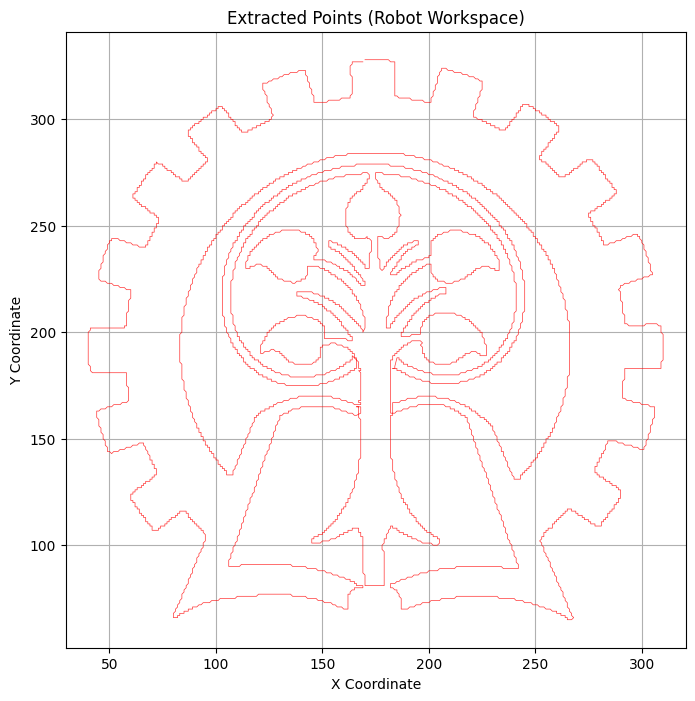

In [7]:
visualize_points(sorted_path, "plot")

Although now you see that some of the points earlier highlighted aren't there anymore, that's probably alright. It's surely better than the mess that's created by dragging the pen.

Now the situation has mellowed down so much. We basically have the (x, y) points to plot, and the path to plot. The absolute next thing we want to do is obviously deal with the inverse kinematics math.

# The Math - Inverse Kinematics

Here we basically need to use Inverse Kinematics because Forward Kinematics tells us the point based on arm parameters, which isn't useful.  
We know the points, we need to figure out the angles ($\theta1$ and $\theta2$).  
For this, we need to have some understanding of the Math. 

Let $L_1$ be the length of the first link (shoulder to elbow) and $L_2$ by the length of the second link (elbow to end effector). Our target is `(x, y)`. 

So obviously the first approach would be to figure out the distance between origin and `(x, y)`.  
If the length is `r`, then $r^2 = x^2 + y^2$

Let's visualise I bit...  
$$\text{Made it on Canva and it took quite some time so hope it helps :}$$
<div align="center">
    <img src="../demo/theory.png" width=350>
</div>

Now that we know the length, we basically figure out the $\theta s$ using `Law of Cosines`.  
Consider the triangle formed by $L_1$, $L_2$ and $r$.  
  
$x^2 + y^2 = L_1^2 + L_2^2 - 2L_1L_2 \cos(180^\circ - \theta_2)$  
  
Since $\cos(180^\circ - \theta_2) = -\cos(\theta_2)$, this simplifies to:  
$$\cos(\theta_2) = \frac{x^2 + y^2 - L_1^2 - L_2^2}{2L_1L_2}$$

Then we're just solving for $\theta_2$ like this -
$$\theta_2 = \arccos\left(\frac{x^2 + y^2 - L_1^2 - L_2^2}{2L_1L_2}\right)$$
  
$NOTE :-$  
$\text{This yields two possible solutions corresponding to "elbow-up" and "elbow-down" configurations.}$  
$\text{For simplicity in drawing, I'll consistently use the positive root only}$  

Similarly solving for $\theta_1$ -  
$$\theta_1 = \text{atan2}(y, x) - \text{atan2}(L_2 \sin(\theta_2), L_1 + L_2 \cos(\theta_2))$$  

So with all this done, we can move onto the code part...

In [8]:
# I'm writing a function that takes in coordinates and arm lengths to give out angles
def calculate_ik(x, y, L1, L2):
    # First we find r, or distance from origin
    distance_sq = x**2 + y**2

    # Then check if the point is reachable
    if distance_sq > (L1 + L2)**2:
        # For a drawing simulation, if a point is out of bounds, 
        # we can return None, or have the arm point towards it at max extension.
        # Returning None is safer to avoid drawing errors.
        return None, None

    # If things are alright, calculate theta2 next
    cos_theta2 = (distance_sq - L1**2 - L2**2) / (2 * L1 * L2)
    
    # Due to floating point errors, cos_theta2 might occasionally be 1.0000000001
    # We clip it to the valid domain [-1, 1] to prevent math domain errors.
    cos_theta2 = np.clip(cos_theta2, -1.0, 1.0)
    theta2 = np.arccos(cos_theta2)

    # Next target is theta1
    angle_to_target = np.arctan2(y, x)
    angle_offset = np.arctan2(L2 * np.sin(theta2), L1 + L2 * np.cos(theta2))
    theta1 = angle_to_target - angle_offset
    # I'm using arctan2 because it handles all four quadrants efficiently

    # So now that we're done calculating, we can return
    return theta1, theta2

In [9]:
# We're done with the function but I want to run a quick test once
t1, t2 = calculate_ik(150, 150, 128, 176)
print(f"Theta1: {np.degrees(t1):.2f}°, Theta2: {np.degrees(t2):.2f}°")

Theta1: -10.95°, Theta2: 93.00°


Okay this is running perfectly! We're done with the Math Part. Now all we have to run is the simulation of the robotic arm and we're done... Let's move ->  

I'm going to write a function that basically renders the entire plotting process using OpenCV.  
Here's how I'm going to do it...  

# Simulation and Control

In [12]:
def simulate_robot(points, L1, L2, delay_ms=5):
    # Sometimes, the Python Window doesn't pop-up
    # So you never know if it's a lag or you just can't see it
    # Hence I decided to add this line, it shows that the function has been called
    print("Starting OpenCV simulation... Look for a new window to pop up!")
    
    # Setup the Canvas
    # Determine window size based on max reach of the arm
    max_reach = int(L1 + L2)
    canvas_size = max_reach
    
    # Create two canvases:
    # - drawing_canvas: Persistent white background that holds the red "ink" trail
    # - frame: Temporary canvas for rendering the arm on top of the ink every frame
    drawing_canvas = np.ones((canvas_size, canvas_size, 3), dtype=np.uint8) * 255
    
    # Place the robot base in the bottom-left region of the window
    origin_x = 50
    origin_y = canvas_size - 50
    
    # Helper to convert physical Cartesian math (X, Y) to OpenCV pixel coordinates
    def to_img_coords(x, y):
        return (int(origin_x + x), int(origin_y - y))
        
    base_pt = to_img_coords(0, 0)
    prev_ee_pt = None 
    # Stores the Previous position of end-effector
    
    # Main Animation Loop
    for i, point in enumerate(points):
        target_x, target_y = point[0], point[1]
        
        # Calculate Joint Angles
        t1, t2 = calculate_ik(target_x, target_y, L1, L2)
        
        if t1 is None or t2 is None:
            continue # Skip unreachable points
            
        # Calculate physical joint positions
        elbow_x = L1 * np.cos(t1)
        elbow_y = L1 * np.sin(t1)
        ee_x = elbow_x + L2 * np.cos(t1 + t2)
        ee_y = elbow_y + L2 * np.sin(t1 + t2)
        
        # Convert physical positions to OpenCV coordinates
        elbow_pt = to_img_coords(elbow_x, elbow_y)
        ee_pt = to_img_coords(ee_x, ee_y)
        
        # Draw the permanent "Ink" on the background canvas
        if prev_ee_pt is not None:
            cv2.line(drawing_canvas, prev_ee_pt, ee_pt, (0, 0, 255), 1, cv2.LINE_AA)
        prev_ee_pt = ee_pt
        
        # Copy the background to draw the arm without leaving ghost trails
        frame = drawing_canvas.copy()
        
        # Draw Link 1 (Blue) and Link 2 (Green)
        cv2.line(frame, base_pt, elbow_pt, (255, 0, 0), 8, cv2.LINE_AA)
        cv2.line(frame, elbow_pt, ee_pt, (0, 255, 0), 8, cv2.LINE_AA)
        
        # Draw Joints (Black)
        cv2.circle(frame, base_pt, 6, (0, 0, 0), -1)
        cv2.circle(frame, elbow_pt, 6, (0, 0, 0), -1)
        cv2.circle(frame, ee_pt, 4, (0, 0, 0), -1)
        
        # Add Progress Text
        cv2.putText(frame, f"Drawing Point: {i+1}/{len(points)}", (20, 30), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 0), 2)
        
        # Display the frame
        cv2.imshow("OpenCV 2-DOF Robot Simulation", frame)
        
        # Wait for 'delay_ms'. If 'q' is pressed, break the loop early...
        if cv2.waitKey(delay_ms) & 0xFF == ord('q'):
            print("\nSimulation interrupted by user.")
            break
            
    print("Drawing complete! Press ANY key in the OpenCV window to close it.")
    cv2.waitKey(0) # Keep window open at the end until a key is pressed
    cv2.destroyAllWindows() # Crucial for Jupyter to not freeze

# Visualisation

The function has been written, I'm going to call it with the sorted_path array in hand...  
Let's see how it turns out.

In [13]:
simulate_robot(sorted_path, L1=250, L2=250, delay_ms=5)

Starting OpenCV simulation... Look for a new window to pop up!

Simulation interrupted by user.
Drawing complete! Press ANY key in the OpenCV window to close it.


So yeah we have a fair idea how it works now.  
To see the simulation, I'm going to attach a GIF of the working here.  
However, this is rendering at 160fps.  
The actual animation of the simulation is much slower, and you can see it once you run the cell.  
<div align="center">
    <img src="../demo/arm_simulator_160fps.gif">
</div>

$$\text{Simulated Robotic Arm Animation}$$

I've completed pretty much everything now, so I'm concluding the project. Thank You!